# 08 双均线分级仓位研究

本阶段不再搜索新的均线参数。

固定比较：

1. 原始二元仓位 10/40；
2. 分级仓位 10/40；
3. 买入持有。

分级仓位第一版：

- 多头均线：100%；
- 均线空头但出现短期反弹：30%；
- 其他情况：0%。

目标是判断部分仓位能否减少错过上涨，同时保留大部分下跌保护。

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "ma_graded_position"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.width",
    180,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.4f}",
)

plt.rcParams[
    "axes.unicode_minus"
] = False

from matplotlib import font_manager


def configure_chinese_font() -> str | None:
    """
    从当前系统已安装字体中选择一个支持中文的字体。
    """
    preferred_fonts = [
        "Microsoft YaHei",
        "Microsoft YaHei UI",
        "SimHei",
        "SimSun",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]

    installed_fonts = {
        font.name
        for font in font_manager.fontManager.ttflist
    }

    for font_name in preferred_fonts:
        if font_name in installed_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [
                font_name
            ]
            plt.rcParams["axes.unicode_minus"] = False

            print(
                "Matplotlib 中文字体：",
                font_name,
            )

            return font_name

    print(
        "没有发现可用的中文字体，"
        "图中的中文可能无法正常显示"
    )

    return None


chinese_font = configure_chinese_font()

%load_ext autoreload
%autoreload 2

from backtest import (
    run_batch_ma_backtest,
)

from graded_position_strategy import (
    run_batch_graded_ma_backtest,
    summarize_batch_period,
    compare_strategy_summaries,
    summarize_strategy_comparison,
    build_timing_attribution_detail,
    summarize_timing_attribution,
    summarize_position_state_performance,
    build_incremental_daily_detail,
    summarize_incremental_effect,
    plot_stock_nav_comparison,
)



Matplotlib 中文字体： Microsoft YaHei


In [2]:
DEVELOPMENT_STOCK_LIST = [
    "000001",
    "000002",
    "300750",
    "600036",
    "600519",
]

FAST_WINDOW = 10
SLOW_WINDOW = 40

REBOUND_WINDOW = 5
PARTIAL_POSITION = 0.30

REBOUND_RETURN_THRESHOLD = 0.0

COMMISSION_RATE = 0.0003
SLIPPAGE_RATE = 0.0002

DEVELOPMENT_START_DATE = "2018-01-01"
DEVELOPMENT_END_DATE = "2024-12-31"

graded_rule = {
    "fast_window": FAST_WINDOW,
    "slow_window": SLOW_WINDOW,
    "rebound_window": REBOUND_WINDOW,
    "partial_position": PARTIAL_POSITION,
    "rebound_return_threshold": (
        REBOUND_RETURN_THRESHOLD
    ),
    "start_date": DEVELOPMENT_START_DATE,
    "end_date": DEVELOPMENT_END_DATE,
}

graded_rule

{'fast_window': 10,
 'slow_window': 40,
 'rebound_window': 5,
 'partial_position': 0.3,
 'rebound_return_threshold': 0.0,
 'start_date': '2018-01-01',
 'end_date': '2024-12-31'}

## 原始二元策略。即只有空仓和满仓

In [3]:
binary_summary_all, binary_results = (
    run_batch_ma_backtest(
        stock_list=DEVELOPMENT_STOCK_LIST,
        fast_window=FAST_WINDOW,
        slow_window=SLOW_WINDOW,
        commission_rate=COMMISSION_RATE,
        slippage_rate=SLIPPAGE_RATE,
        annual_risk_free_rate=0.0,
        trading_days=252,
        save_result=False,
    )
)

正在回测：000001
正在回测：000002
正在回测：300750
正在回测：600036
正在回测：600519


## 分级仓位

In [ ]:

graded_summary_all, graded_results = (
    run_batch_graded_ma_backtest(
        stock_list=DEVELOPMENT_STOCK_LIST,
        fast_window=10,
        slow_window=40,
        rebound_window=5,
        partial_position=0.30,
        signal_version="v1",
        rebound_return_threshold=0.0,
        commission_rate=0.0003,
        slippage_rate=0.0002,
        annual_risk_free_rate=0.0,
        trading_days=252,
        save_result=False,
    )
)

正在回测分级仓位策略：000001
正在回测分级仓位策略：000002
正在回测分级仓位策略：300750
正在回测分级仓位策略：600036
正在回测分级仓位策略：600519


## 回测数据分析

In [ ]:
binary_period_summary = (
    summarize_batch_period(
        batch_results=binary_results,
        period_name="development",
        start_date=DEVELOPMENT_START_DATE,
        end_date=DEVELOPMENT_END_DATE,
        strategy_name="binary_10_40",
        annual_risk_free_rate=0.0,
        trading_days=252,
    )
)

display(binary_period_summary)

,period,symbol,start_date,end_date,trade_days,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,strategy_calmar,benchmark_cumulative_return,benchmark_annual_return,benchmark_annual_volatility,benchmark_sharpe,benchmark_max_drawdown,benchmark_calmar,excess_annual_return,sharpe_diff,drawdown_improvement,exposure,buy_count,sell_count,total_trade_count,total_transaction_cost,strategy_name,total_turnover,full_position_rate,partial_position_rate,cash_rate
0,development,300750,2018-08-07,2024-12-31,1554,6.8909,0.3979,0.3699,1.0879,-0.3350,1.1877,6.1282,0.3751,0.4654,0.9147,-0.6288,0.5965,0.0229,0.1732,0.2937,0.5611,21,20,41,0.0205,binary_10_40,41.0000,0.5611,0.0000,0.4389
1,development,600519,2018-01-02,2024-12-31,1699,0.2829,0.0376,0.2102,0.2809,-0.4233,0.0889,1.5030,0.1458,0.3060,0.5974,-0.4748,0.3070,-0.1081,-0.3165,0.0515,0.5227,24,24,48,0.0240,binary_10_40,48.0000,0.5227,0.0000,0.4773
2,development,600036,2018-01-02,2024-12-31,1699,-0.1623,-0.0259,0.2068,-0.0241,-0.3622,-0.0716,0.7728,0.0886,0.2925,0.4360,-0.5093,0.1740,-0.1146,-0.4601,0.1472,0.5185,29,29,58,0.0290,binary_10_40,58.0000,0.5185,0.0000,0.4815
3,development,000001,2018-01-02,2024-12-31,1699,-0.2492,-0.0416,0.2336,-0.0657,-0.5162,-0.0806,0.0570,0.0083,0.3201,0.1848,-0.6231,0.0132,-0.0499,-0.2506,0.1069,0.4715,25,25,50,0.0250,binary_10_40,50.0000,0.4715,0.0000,0.5285
4,development,000002,2018-01-02,2024-12-31,1699,-0.7544,-0.1880,0.2494,-0.7106,-0.8436,-0.2229,-0.6907,-0.1597,0.3711,-0.2849,-0.7999,-0.1997,-0.0283,-0.4257,-0.0437,0.3985,29,29,58,0.0290,binary_10_40,58.0000,0.3985,0.0000,0.6015


In [ ]:
graded_period_summary = (
    summarize_batch_period(
        batch_results=graded_results,
        period_name="development",
        start_date="2018-01-01",
        end_date="2024-12-31",
        strategy_name="graded_v1",
        annual_risk_free_rate=0.0,
        trading_days=252,
    )
)
display(graded_period_summary)

,period,symbol,start_date,end_date,trade_days,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,strategy_calmar,benchmark_cumulative_return,benchmark_annual_return,benchmark_annual_volatility,benchmark_sharpe,benchmark_max_drawdown,benchmark_calmar,excess_annual_return,sharpe_diff,drawdown_improvement,exposure,buy_count,sell_count,total_trade_count,total_transaction_cost,strategy_name,total_turnover,full_position_rate,partial_position_rate,cash_rate
0,development,300750,2018-08-07,2024-12-31,1554,6.4716,0.3856,0.3728,1.0585,-0.3547,1.0872,6.1282,0.3751,0.4654,0.9147,-0.6288,0.5965,0.0105,0.1438,0.2741,0.6094,83,68,151,0.0340,graded_10_40,68.0000,0.5611,0.1609,0.2780
1,development,600519,2018-01-02,2024-12-31,1699,0.3421,0.0446,0.2141,0.3109,-0.4184,0.1066,1.5030,0.1458,0.3060,0.5974,-0.4748,0.3070,-0.1012,-0.2865,0.0564,0.5770,107,87,194,0.0426,graded_10_40,85.2000,0.5227,0.1813,0.2961
2,development,600036,2018-01-02,2024-12-31,1699,-0.1191,-0.0186,0.2101,0.0151,-0.3702,-0.0503,0.7728,0.0886,0.2925,0.4360,-0.5093,0.1740,-0.1073,-0.4209,0.1392,0.5779,118,96,214,0.0485,graded_10_40,97.0000,0.5185,0.1978,0.2837
3,development,000001,2018-01-02,2024-12-31,1699,-0.2410,-0.0401,0.2371,-0.0544,-0.5182,-0.0773,0.0570,0.0083,0.3201,0.1848,-0.6231,0.0132,-0.0483,-0.2393,0.1049,0.5235,110,88,198,0.0436,graded_10_40,87.2000,0.4715,0.1736,0.3549
4,development,000002,2018-01-02,2024-12-31,1699,-0.7553,-0.1885,0.2543,-0.6944,-0.8475,-0.2224,-0.6907,-0.1597,0.3711,-0.2849,-0.7999,-0.1997,-0.0287,-0.4095,-0.0476,0.4590,129,108,237,0.0525,graded_10_40,105.1000,0.3985,0.2019,0.3996


## 正确性测试

In [7]:
allowed_positions = np.array(
    [
        0.0,
        PARTIAL_POSITION,
        1.0,
    ]
)

for symbol, result in graded_results.items():
    position_is_valid = result[
        "position"
    ].apply(
        lambda value: np.isclose(
            value,
            allowed_positions,
        ).any()
    )

    assert position_is_valid.all(), (
        f"{symbol} 存在非法仓位"
    )

print("分级仓位取值检查通过")

allowed_positions = np.array(
    [
        0.0,
        PARTIAL_POSITION,
        1.0,
    ]
)

for symbol, result in graded_results.items():
    position_is_valid = result[
        "position"
    ].apply(
        lambda value: np.isclose(
            value,
            allowed_positions,
        ).any()
    )

    assert position_is_valid.all(), (
        f"{symbol} 存在非法仓位"
    )

print("分级仓位取值检查通过")

for symbol, result in graded_results.items():
    expected_position = (
        result["signal"]
        .shift(1)
        .fillna(0.0)
    )

    assert np.allclose(
        result["position"],
        expected_position,
    ), (
        f"{symbol} 仓位延迟检查失败"
    )

print("信号延迟检查通过")

one_way_cost = (
    COMMISSION_RATE
    + SLIPPAGE_RATE
)

for symbol, result in graded_results.items():
    expected_cost = (
        result[
            "position_change"
        ].abs()
        * one_way_cost
    )

    assert np.allclose(
        result[
            "transaction_cost"
        ],
        expected_cost,
    ), (
        f"{symbol} 交易成本检查失败"
    )

print("交易成本检查通过")

for symbol, result in graded_results.items():
    expected_gross_return = (
        result["position"]
        * result[
            "asset_return"
        ].fillna(0.0)
    )

    expected_net_return = (
        expected_gross_return
        - result[
            "transaction_cost"
        ]
    )

    assert np.allclose(
        result[
            "gross_strategy_return"
        ],
        expected_gross_return,
    )

    assert np.allclose(
        result[
            "strategy_return"
        ],
        expected_net_return,
    )

print("策略收益公式检查通过")

分级仓位取值检查通过
分级仓位取值检查通过
信号延迟检查通过
交易成本检查通过
策略收益公式检查通过


## 策略比较

In [8]:
strategy_comparison = (
    compare_strategy_summaries(
        binary_summary=(
            binary_period_summary
        ),
        graded_summary=(
            graded_period_summary
        ),
    )
)

comparison_columns = [
    "symbol",
    "strategy_annual_return_binary",
    "strategy_annual_return_graded",
    "annual_return_improvement",
    "strategy_sharpe_binary",
    "strategy_sharpe_graded",
    "sharpe_improvement",
    "strategy_max_drawdown_binary",
    "strategy_max_drawdown_graded",
    "drawdown_improvement_vs_binary",
    "excess_return_improvement",
    "exposure_change",
    "turnover_change",
    "transaction_cost_change",
]

display(
    strategy_comparison[
        comparison_columns
    ]
)

,symbol,strategy_annual_return_binary,strategy_annual_return_graded,annual_return_improvement,strategy_sharpe_binary,strategy_sharpe_graded,sharpe_improvement,strategy_max_drawdown_binary,strategy_max_drawdown_graded,drawdown_improvement_vs_binary,excess_return_improvement,exposure_change,turnover_change,transaction_cost_change
0,600036,-0.0259,-0.0186,0.0073,-0.0241,0.0151,0.0392,-0.3622,-0.3702,-0.0080,0.0073,0.0593,39.0000,0.0195
1,600519,0.0376,0.0446,0.0070,0.2809,0.3109,0.0300,-0.4233,-0.4184,0.0049,0.0070,0.0544,37.2000,0.0186
2,000002,-0.1880,-0.1885,-0.0004,-0.7106,-0.6944,0.0162,-0.8436,-0.8475,-0.0039,-0.0004,0.0606,47.1000,0.0235
3,000001,-0.0416,-0.0401,0.0015,-0.0657,-0.0544,0.0113,-0.5162,-0.5182,-0.0020,0.0015,0.0521,37.2000,0.0186
4,300750,0.3979,0.3856,-0.0123,1.0879,1.0585,-0.0294,-0.3350,-0.3547,-0.0196,-0.0123,0.0483,27.0000,0.0135


In [9]:
strategy_comparison_summary = (
    summarize_strategy_comparison(
        strategy_comparison
    )
)

display(
    strategy_comparison_summary
)

,stock_count,avg_annual_return_improvement,median_annual_return_improvement,annual_return_win_rate,avg_sharpe_improvement,median_sharpe_improvement,sharpe_win_rate,avg_calmar_improvement,calmar_win_rate,avg_drawdown_improvement,drawdown_win_rate,avg_excess_return_improvement,excess_return_win_rate,avg_exposure_change,avg_trade_count_change,avg_turnover_change,avg_transaction_cost_change
0,5,0.0006,0.0015,0.6000,0.0135,0.0162,0.8000,-0.0115,0.8000,-0.0057,0.2000,0.0006,0.6000,0.0549,147.8000,37.5000,0.0187


## 策略失效分析

In [10]:
binary_attribution_detail = (
    build_timing_attribution_detail(
        batch_results=binary_results,
        strategy_name="binary_10_40",
        start_date=DEVELOPMENT_START_DATE,
        end_date=DEVELOPMENT_END_DATE,
    )
)

graded_attribution_detail = (
    build_timing_attribution_detail(
        batch_results=graded_results,
        strategy_name="graded_10_40",
        start_date=DEVELOPMENT_START_DATE,
        end_date=DEVELOPMENT_END_DATE,
    )
)

attribution_detail = pd.concat(
    [
        binary_attribution_detail,
        graded_attribution_detail,
    ],
    ignore_index=True,
)

In [11]:
attribution_summary = (
    summarize_timing_attribution(
        attribution_detail=(
            attribution_detail
        ),
        group_columns=[
            "strategy_name",
        ],
    )
)

display(
    attribution_summary[
        [
            "strategy_name",
            "active_return_sum",
            "active_log_return_sum",
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
            "net_timing_benefit",
            "benefit_cost_ratio",
        ]
    ]
)

,strategy_name,active_return_sum,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,net_timing_benefit,benefit_cost_ratio
0,binary_10_40,-2.8560,-1.8892,33.9557,31.2272,0.1275,-2.7285,0.9162
1,graded_10_40,-2.7774,-1.8412,30.3885,27.8324,0.2213,-2.5561,0.9093


In [12]:
position_state_summary = (
    summarize_position_state_performance(
        attribution_detail=(
            graded_attribution_detail
        ),
        group_columns=[
            "strategy_name",
            "position_state",
        ],
    )
)

display(
    position_state_summary[
        [
            "strategy_name",
            "position_state",
            "observation_count",
            "observation_rate",
            "average_position",
            "strategy_mean_daily_return",
            "benchmark_mean_daily_return",
            "active_mean_daily_return",
            "active_log_return_sum",
            "missed_upside_sum",
            "avoided_downside_sum",
            "transaction_cost_sum",
        ]
    ]
)

,strategy_name,position_state,observation_count,observation_rate,average_position,strategy_mean_daily_return,benchmark_mean_daily_return,active_mean_daily_return,active_log_return_sum,missed_upside_sum,avoided_downside_sum,transaction_cost_sum
0,graded_10_40,cash,2699,0.3232,0.0000,-0.0000,0.0008,-0.0008,-1.6328,-22.0651,19.9113,0.1080
1,graded_10_40,full,4119,0.4933,1.0000,0.0004,0.0004,-0.0000,-0.0479,0.0000,0.0000,0.0479
2,graded_10_40,partial,1532,0.1835,0.3000,0.0001,0.0004,-0.0003,-0.1605,-8.3234,7.9211,0.0653


In [13]:
partial_state_result = (
    position_state_summary.loc[
        position_state_summary[
            "position_state"
        ] == "partial"
    ]
)

display(partial_state_result)

,strategy_name,position_state,observation_count,stock_count,average_position,strategy_mean_daily_return,benchmark_mean_daily_return,active_mean_daily_return,active_return_sum,active_log_return_sum,missed_upside_sum,avoided_downside_sum,transaction_cost_sum,observation_rate
2,graded_10_40,partial,1532,5,0.3000,0.0001,0.0004,-0.0003,-0.4676,-0.1605,-8.3234,7.9211,0.0653,0.1835


## 精确分析新仓位效果

In [14]:
incremental_detail = (
    build_incremental_daily_detail(
        binary_results=binary_results,
        graded_results=graded_results,
        start_date=DEVELOPMENT_START_DATE,
        end_date=DEVELOPMENT_END_DATE,
    )
)

display(
    incremental_detail[
        [
            "date",
            "symbol",
            "asset_return",
            "position_binary",
            "position_graded",
            "position_increment",
            "incremental_state",
            "incremental_gross_return",
            "incremental_transaction_cost",
            "incremental_net_return",
        ]
    ].head()
)

,date,symbol,asset_return,position_binary,position_graded,position_increment,incremental_state,incremental_gross_return,incremental_transaction_cost,incremental_net_return
0,2018-01-02,000001,0.0295,1.0000,1.0000,0.0000,same_exposure,0.0000,0.0000,0.0000
1,2018-01-03,000001,-0.0267,1.0000,1.0000,0.0000,same_exposure,0.0000,0.0000,0.0000
2,2018-01-04,000001,-0.0059,1.0000,1.0000,0.0000,same_exposure,0.0000,0.0000,0.0000
3,2018-01-05,000001,0.0039,1.0000,1.0000,0.0000,same_exposure,0.0000,0.0000,0.0000
4,2018-01-08,000001,-0.0255,0.0000,0.0000,0.0000,same_exposure,0.0000,0.0000,0.0000


In [15]:
incremental_summary = (
    summarize_incremental_effect(
        incremental_detail=(
            incremental_detail
        ),
        group_columns=[
            "incremental_state",
        ],
    )
)

display(incremental_summary)

,incremental_state,observation_count,stock_count,average_position_increment,average_asset_return,incremental_gross_return_sum,incremental_transaction_cost_sum,incremental_net_return_sum,incremental_log_return_sum,positive_incremental_day_rate
0,added_exposure_up,699,5,0.3000,0.0170,3.5672,0.0295,3.5376,3.5192,0.9971
1,added_exposure_flat,35,5,0.3000,0.0000,0.0000,0.0018,-0.0018,-0.0018,0.0000
2,same_exposure,6818,5,0.0000,0.0006,0.0000,0.0319,-0.0319,-0.0320,0.0157
3,added_exposure_down,798,5,0.3000,-0.0142,-3.3948,0.0304,-3.4252,-3.4374,0.0000


In [17]:
added_exposure_detail = (
    incremental_detail.loc[
        incremental_detail[
            "position_increment"
        ] > 0
    ]
)

added_exposure_result = {
    "observation_count": len(
        added_exposure_detail
    ),
    "stock_count": (
        added_exposure_detail[
            "symbol"
        ].nunique()
    ),
    "average_position_increment": (
        added_exposure_detail[
            "position_increment"
        ].mean()
    ),
    "gross_return_increment_sum": (
        added_exposure_detail[
            "incremental_gross_return"
        ].sum()
    ),
    "transaction_cost_increment_sum": (
        added_exposure_detail[
            "incremental_transaction_cost"
        ].sum()
    ),
    "net_return_increment_sum": (
        added_exposure_detail[
            "incremental_net_return"
        ].sum()
    ),
    "log_return_increment_sum": (
        added_exposure_detail[
            "incremental_log_return"
        ].sum()
    ),
    "positive_day_rate": (
        (
            added_exposure_detail[
                "incremental_net_return"
            ]
            > 0
        ).mean()
    ),
}

display(
    pd.DataFrame(
        [added_exposure_result]
    )
)

,observation_count,stock_count,average_position_increment,gross_return_increment_sum,transaction_cost_increment_sum,net_return_increment_sum,log_return_increment_sum,positive_day_rate
0,1532,5,0.3000,0.1724,0.0618,0.1106,0.0800,0.4550


In [18]:
stock_incremental_summary = (
    summarize_incremental_effect(
        incremental_detail=(
            incremental_detail
        ),
        group_columns=[
            "symbol",
        ],
    )
)

display(
    stock_incremental_summary.sort_values(
        "incremental_log_return_sum",
        ascending=False,
    )
)

,symbol,observation_count,stock_count,average_position_increment,average_asset_return,incremental_gross_return_sum,incremental_transaction_cost_sum,incremental_net_return_sum,incremental_log_return_sum,positive_incremental_day_rate
0,600036,1699,1,0.0593,0.0005,0.0745,0.0195,0.0550,0.0502,0.1089
1,600519,1699,1,0.0544,0.0007,0.0693,0.0186,0.0507,0.0451,0.0930
2,000001,1699,1,0.0521,0.0002,0.0351,0.0186,0.0165,0.0109,0.0912
3,000002,1699,1,0.0606,-0.0004,0.0281,0.0235,0.0045,-0.0037,0.1012
4,300750,1554,1,0.0483,0.0017,-0.0345,0.0135,-0.0480,-0.0546,0.0862


In [19]:
incremental_stock_win_rate = (
    (
        stock_incremental_summary[
            "incremental_log_return_sum"
        ]
        > 0
    ).mean()
)

print(
    "分级仓位增量收益股票胜率：",
    incremental_stock_win_rate,
)

分级仓位增量收益股票胜率： 0.6


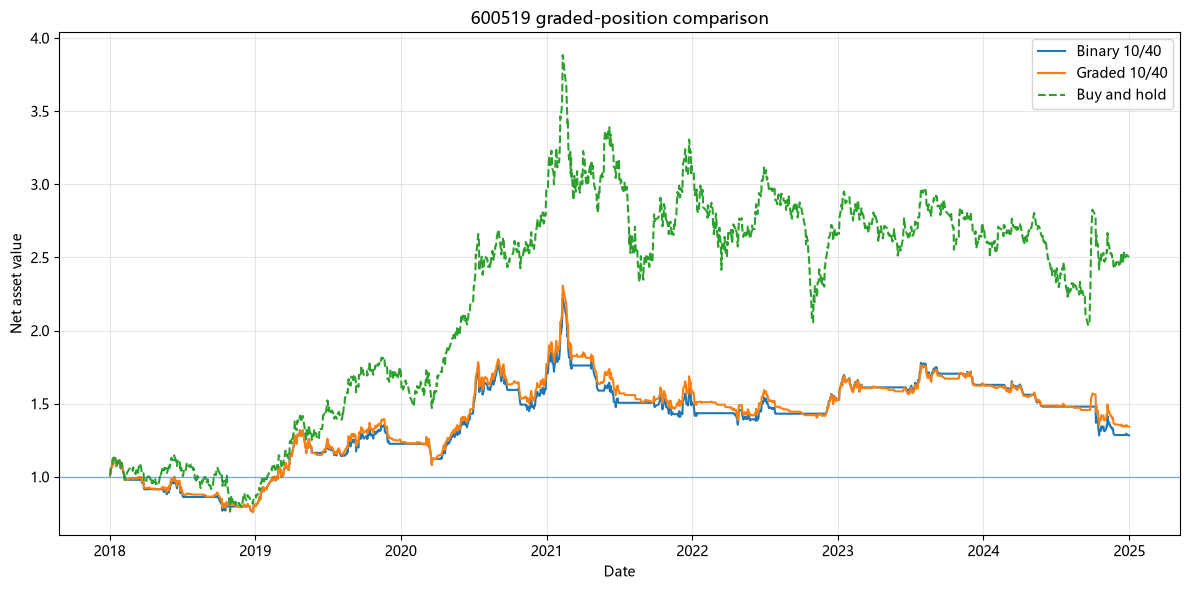

In [20]:
example_symbol = "600519"

fig_nav, ax_nav = (
    plot_stock_nav_comparison(
        binary_result=(
            binary_results[
                example_symbol
            ]
        ),
        graded_result=(
            graded_results[
                example_symbol
            ]
        ),
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
    )
)

plt.show()

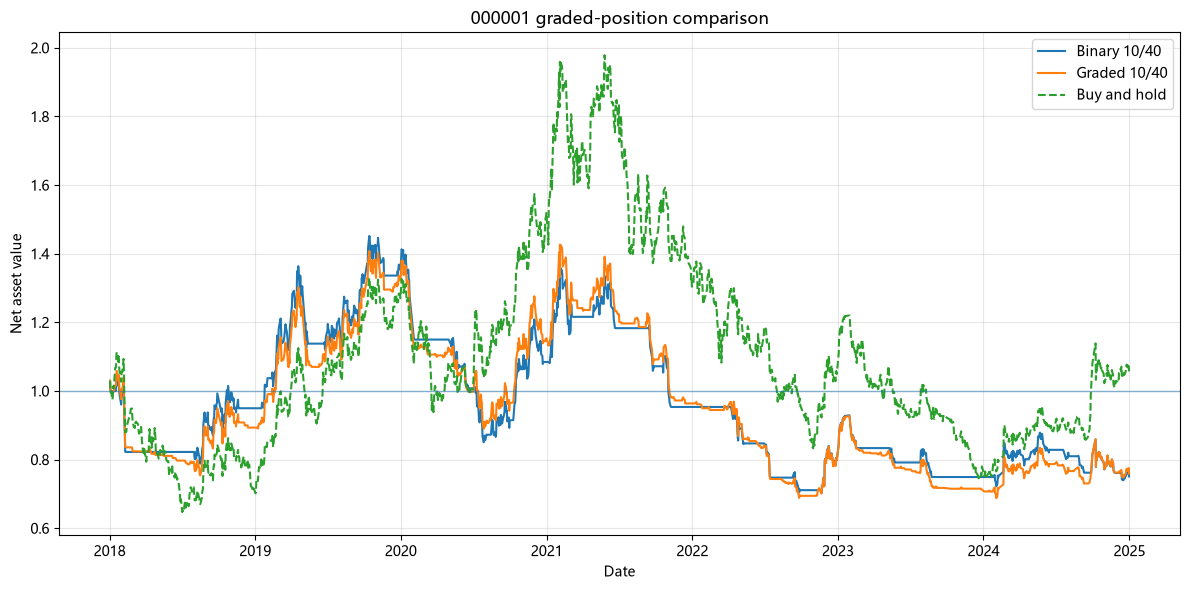

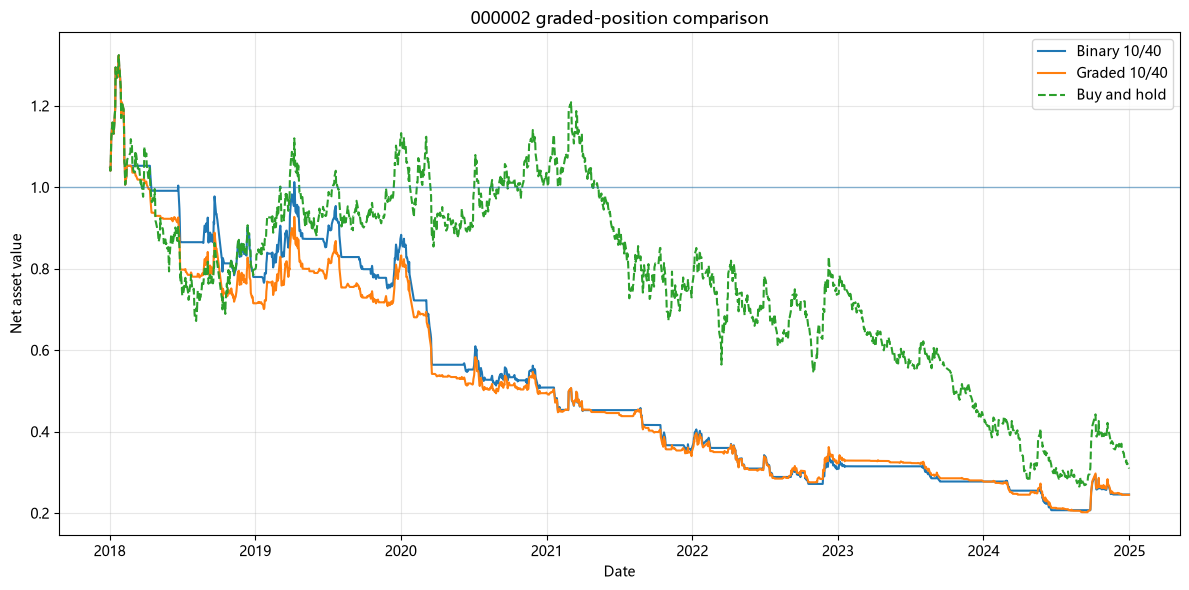

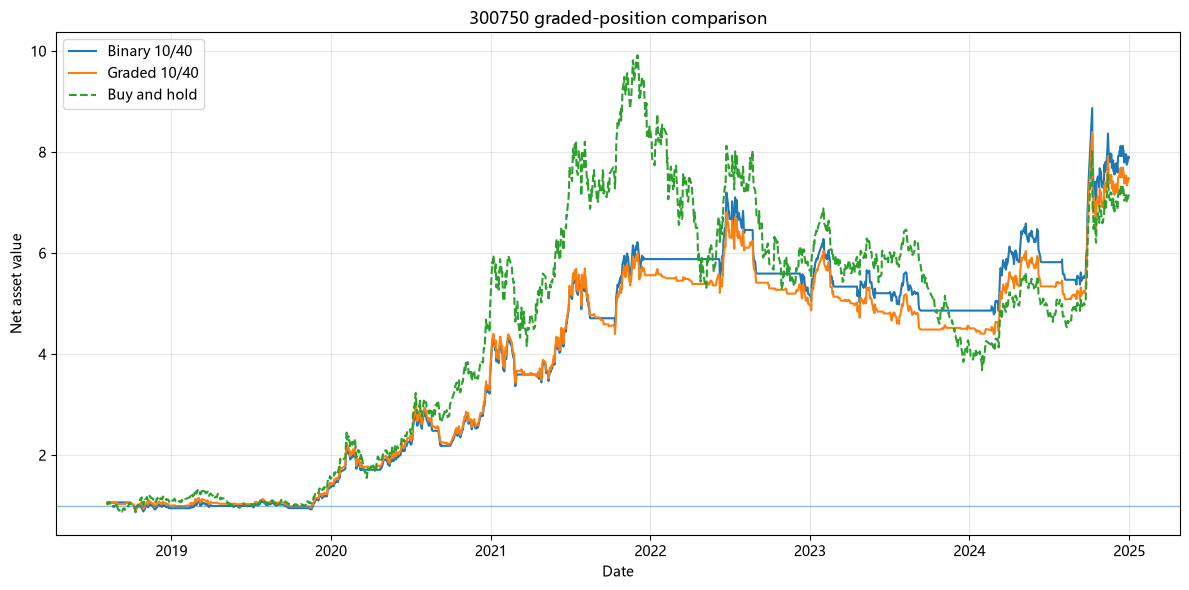

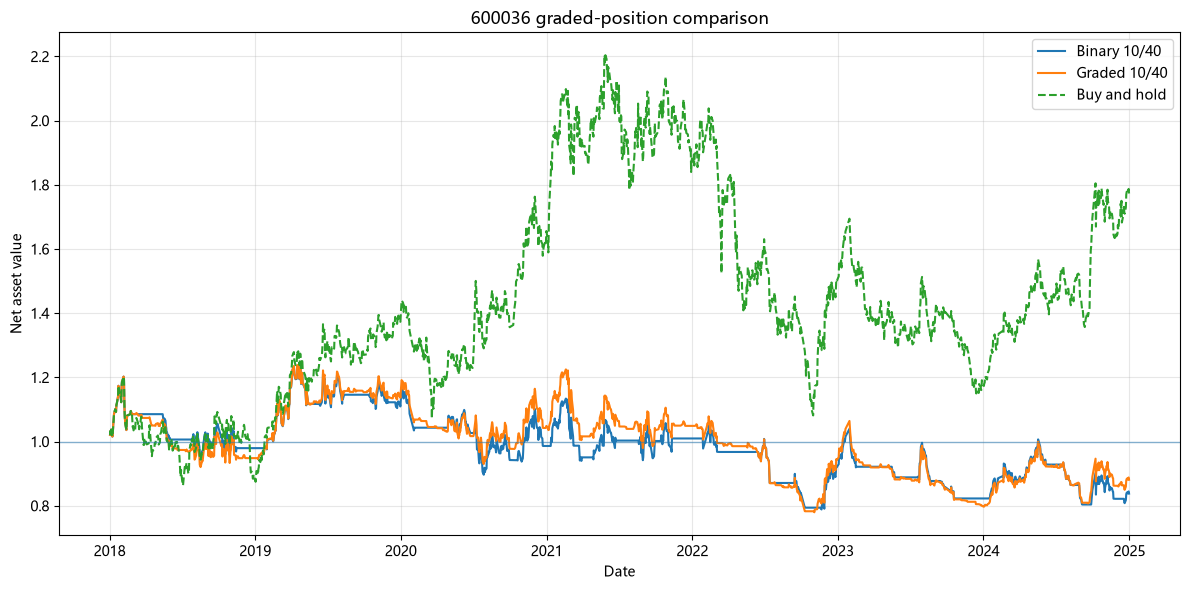

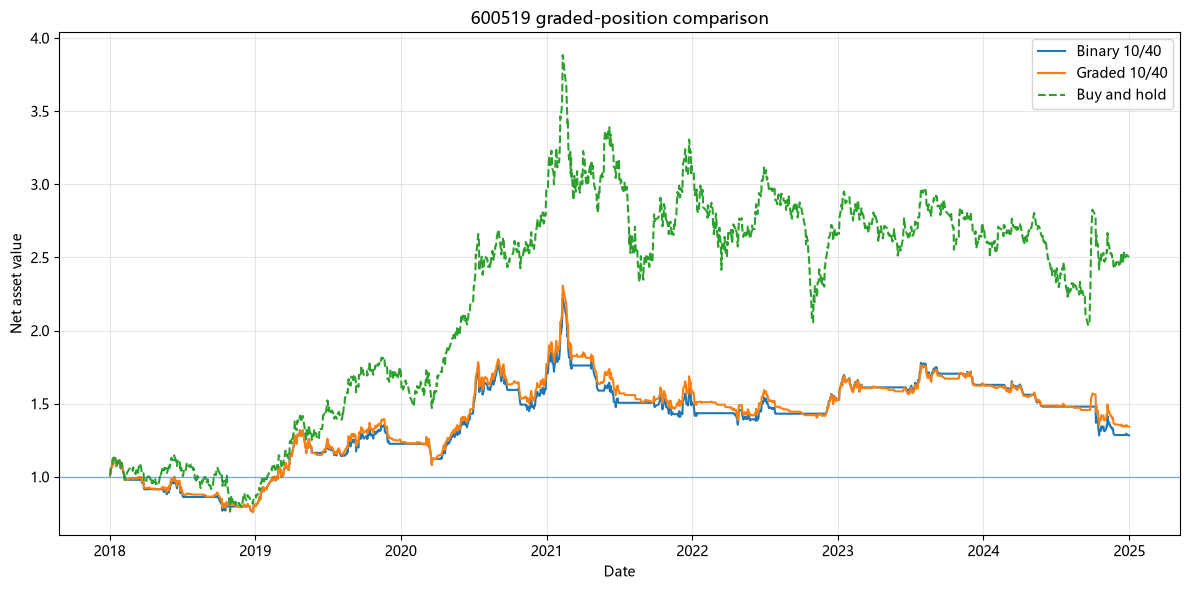

In [21]:
for symbol in DEVELOPMENT_STOCK_LIST:
    if (
        symbol not in binary_results
        or symbol not in graded_results
    ):
        continue

    fig, ax = (
        plot_stock_nav_comparison(
            binary_result=(
                binary_results[symbol]
            ),
            graded_result=(
                graded_results[symbol]
            ),
            start_date=(
                DEVELOPMENT_START_DATE
            ),
            end_date=(
                DEVELOPMENT_END_DATE
            ),
        )
    )

    plt.show()

In [22]:
comparison_row = (
    strategy_comparison_summary.iloc[0]
)

binary_attribution = (
    attribution_summary.loc[
        attribution_summary[
            "strategy_name"
        ] == "binary_10_40"
    ].iloc[0]
)

graded_attribution = (
    attribution_summary.loc[
        attribution_summary[
            "strategy_name"
        ] == "graded_10_40"
    ].iloc[0]
)

research_checks = {
    "错过上涨损失下降": (
        graded_attribution[
            "missed_upside_loss"
        ]
        < binary_attribution[
            "missed_upside_loss"
        ]
    ),
    "benefit_cost_ratio 提高": (
        graded_attribution[
            "benefit_cost_ratio"
        ]
        > binary_attribution[
            "benefit_cost_ratio"
        ]
    ),
    "主动对数收益改善": (
        graded_attribution[
            "active_log_return_sum"
        ]
        > binary_attribution[
            "active_log_return_sum"
        ]
    ),
    "年化收益改善中位数为正": (
        comparison_row[
            "median_annual_return_improvement"
        ]
        > 0
    ),
    "夏普改善胜率至少60%": (
        comparison_row[
            "sharpe_win_rate"
        ]
        >= 0.60
    ),
    "新增仓位增量收益为正": (
        added_exposure_result[
            "log_return_increment_sum"
        ]
        > 0
    ),
    "回撤平均恶化不超过3个百分点": (
        comparison_row[
            "avg_drawdown_improvement"
        ]
        >= -0.03
    ),
}

research_check_table = pd.DataFrame(
    {
        "check": (
            research_checks.keys()
        ),
        "passed": (
            research_checks.values()
        ),
    }
)

display(research_check_table)

,check,passed
0,错过上涨损失下降,True
1,benefit_cost_ratio 提高,False
2,主动对数收益改善,True
3,年化收益改善中位数为正,True
4,夏普改善胜率至少60%,True
5,新增仓位增量收益为正,True
6,回撤平均恶化不超过3个百分点,True


In [23]:
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

binary_period_summary.to_csv(
    REPORT_DIR
    / "binary_period_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

graded_period_summary.to_csv(
    REPORT_DIR
    / "graded_period_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

strategy_comparison.to_csv(
    REPORT_DIR
    / "strategy_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

strategy_comparison_summary.to_csv(
    REPORT_DIR
    / "strategy_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

attribution_summary.to_csv(
    REPORT_DIR
    / "timing_attribution_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

position_state_summary.to_csv(
    REPORT_DIR
    / "position_state_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

incremental_detail.to_csv(
    REPORT_DIR
    / "incremental_daily_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

incremental_summary.to_csv(
    REPORT_DIR
    / "incremental_state_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

stock_incremental_summary.to_csv(
    REPORT_DIR
    / "stock_incremental_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

research_check_table.to_csv(
    REPORT_DIR
    / "research_check_table.csv",
    index=False,
    encoding="utf-8-sig",
)

## 分级仓位策略研究结论

### 1. 总体表现

- 分级仓位年化收益是否提高：平均提高0.0006，胜率仅有0.6
- 分级仓位夏普是否提高：平均提高0.0135，胜率0.8
- 分级仓位最大回撤是否恶化：是，平均恶化-0.0057	，胜率0.2
- 分级仓位超额收益是否提高：是，平均提高0.0006，胜率0.6
- 跨股票夏普改善胜率：0.8

### 2. 错过上涨与规避下跌

- 二元仓位错过上涨损失：33.9557	
- 分级仓位错过上涨损失：30.3885
- 错过上涨减少量：3.5672
- 二元仓位规避下跌收益：31.2272
- 分级仓位规避下跌收益：27.8324	
- 规避下跌减少量：3.3948
- benefit_cost_ratio 是否提高：否，0.9162变到0.9093

### 3. 部分仓位状态

- 部分仓位出现比例：0.1835	
- 部分仓位平均日收益：-0.0001	
- 部分仓位主动收益：-0.0003	
- 部分仓位累计增量收益：0.1106	
- 部分仓位是否真正降低了 missed_upside：是

### 4. 交易与风险

- 平均仓位增加：0.0549	
- 换手变化：37.5000	
- 交易成本变化：0.0187
- 最大回撤变化：-0.0057
- 下跌保护是否明显减弱：略有减弱

### 5. 跨股票稳定性

- 分级仓位优于二元仓位的股票数量：4
- 增量收益股票胜率：0.6000	
- 是否由单只股票贡献大部分收益：否
- 各股票失效原因是否一致：是

### 6. 当前决定

- 是否保留 30% 分级仓位规则：策略提升不大，可考虑继续改进
- 是否需要修改反弹识别条件：是
- 是否存在明显回撤代价：是
- 是否可以冻结规则进入新的外部验证：否

## 第一版分级仓位研究结论

第一版分级仓位策略将均线空头期间满足短期反弹条件的仓位由零提高至 30%。该规则成功减少了错过上涨造成的损失，并在多数股票上轻微提高了夏普比率。

但是，错过上涨损失的减少几乎被规避下跌收益的下降完全抵消。分级仓位使平均仓位、换手率和交易成本上升，同时造成最大回撤恶化。部分仓位出现比例达到 18.35%，说明当前反弹条件过于宽松，部分仓位不再局限于离场后的快速反弹，而是频繁出现在长期均线空头环境中。

因此，第一版规则不能冻结，也不适合进入外部验证。分级仓位的研究方向仍然保留，但下一版不调整 30% 的仓位比例，而是收紧反弹识别条件。

第二版将部分仓位限制在原二元策略退出后的前 20 个交易日，并要求价格重新站上快均线、快均线斜率转正，以及五日反弹幅度达到近期正常波动的一倍以上。目标是减少无效熊市反弹带来的仓位暴露，同时保留对快速反转的提前参与。
